# Model Training - Nepali News Classification

This notebook demonstrates the complete model training pipeline for the Nepali News Classification project.

## Objectives:
1. Load preprocessed data splits (train/validation)
2. Initialize XLM-RoBERTa model and tokenizer
3. Set up training components (optimizer, loss, scheduler)
4. Train the model with class weighting and learning rate scheduling
5. Monitor training progress and visualize metrics
6. Save trained model and training history
7. Evaluate model performance on validation set


In [1]:
# Import required libraries
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR, SequentialLR
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Check Python environment
print("Python environment check:")
print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")

# Add src to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root / 'src'))

# Check if we're in the venv
venv_path = project_root / 'venv'
if 'venv' in sys.executable or str(venv_path) in sys.executable:
    print("✓ Using virtual environment")
else:
    print("⚠ Warning: Not using project venv. Make sure all packages are installed.")

# Import custom modules
try:
    from model import create_model, count_parameters, NepaliNewsClassifier
    from transformers import XLMRobertaTokenizer
    print("✓ Custom modules imported successfully")
except ImportError as e:
    print(f"✗ Error importing custom modules: {e}")
    print("\nPlease ensure:")
    print("1. You're using the project's virtual environment kernel")
    print("2. All required packages are installed")
    raise

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    print(f"✓ CUDA available: {torch.cuda.get_device_name(0)}")
else:
    print("⚠ CUDA not available, using CPU")

# Check device - enforce CUDA usage
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is not available! This training requires GPU. Please ensure CUDA is properly installed and accessible.")
    
device = torch.device('cuda')
print(f"✓ Using device: {device}")
print(f"✓ CUDA Device: {torch.cuda.get_device_name(0)}")
print(f"✓ CUDA Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
print(f"✓ PyTorch version: {torch.__version__}")
print(f"✓ CUDA version: {torch.version.cuda}")


Python environment check:
Python executable: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\venv\Scripts\python.exe
Python version: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
✓ Using virtual environment
✓ Custom modules imported successfully
✓ CUDA available: NVIDIA GeForce RTX 2050
✓ Using device: cuda
✓ CUDA Device: NVIDIA GeForce RTX 2050
✓ CUDA Memory: 4.00 GB
✓ PyTorch version: 2.5.1+cu121
✓ CUDA version: 12.1


## 1. Load Data Splits

Load the preprocessed train and validation datasets.


In [2]:
# Load data splits
data_dir = project_root / 'data' / 'splits'

print("Loading data splits...")
train_df = pd.read_csv(data_dir / 'train.csv')
val_df = pd.read_csv(data_dir / 'val.csv')

print(f"✓ Training samples: {len(train_df):,}")
print(f"✓ Validation samples: {len(val_df):,}")

# Display sample
print("\nSample training data:")
print(train_df.head(3))

# Check label distribution
print("\nTraining label distribution:")
print(train_df['category_id'].value_counts().sort_index())


Loading data splits...
✓ Training samples: 4,878
✓ Validation samples: 1,045

Sample training data:
                                                text     category  \
0                                          ÿþ8 > " G  Agriculture   
1  ﻿सुर्खेत-जिल्ला प्रहरी कार्यालय सुर्खेतले लागू...      Society   
2                                           ÿþ 0 > ,  Agriculture   

   category_id                                          file_path  \
0            0  D:\MSc Islington\NEural Networks and Deep Lear...   
1           15  D:\MSc Islington\NEural Networks and Deep Lear...   
2            0  D:\MSc Islington\NEural Networks and Deep Lear...   

   text_length_after  
0                  9  
1                522  
2                  8  

Training label distribution:
category_id
0     140
1     172
2     432
3     181
4     214
5     420
6     129
7     213
8     444
9     126
10    231
11    174
12     78
13    350
14    385
15    247
16    455
17     83
18    185
19    219
Name: count,

## 2. Load Class Weights and Label Mappings

Load the computed class weights for handling class imbalance.


✓ Loaded class weights for 20 classes
Class weights range: 0.536 - 3.127


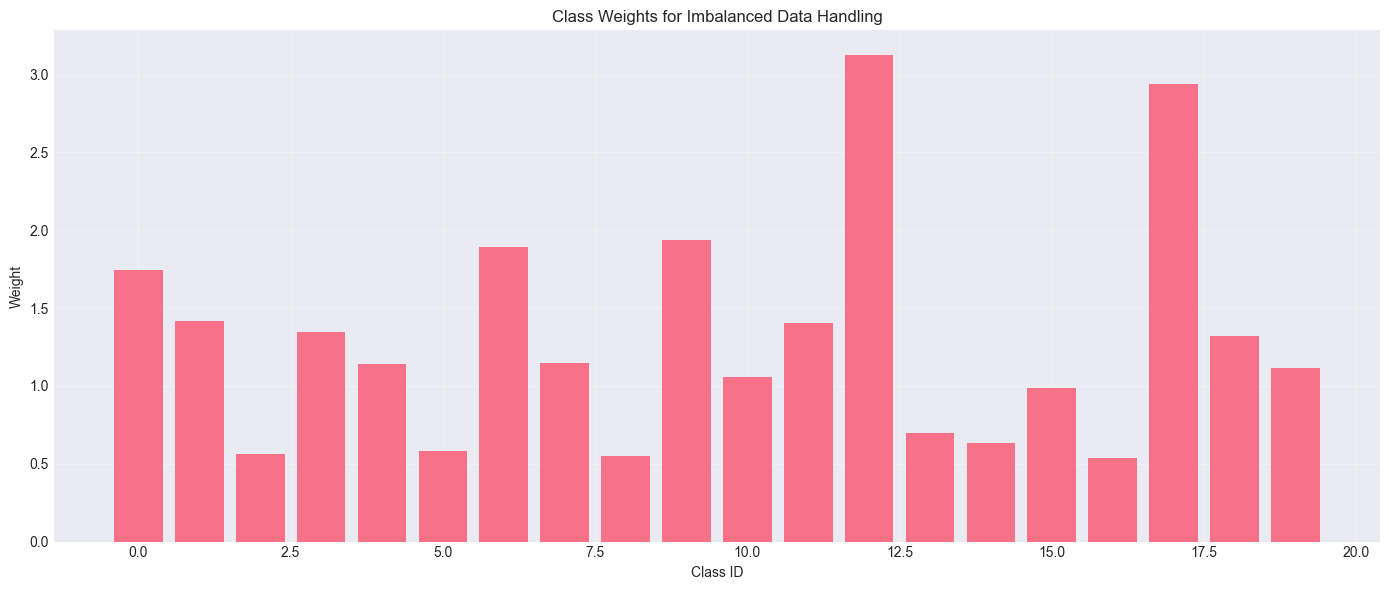


✓ Loaded label mappings
Sample labels: ['Agriculture', 'Automobiles', 'Bank', 'Blog', 'Business']


In [3]:
# Load class weights
class_weights_path = data_dir / 'class_weights.json'
with open(class_weights_path, 'r', encoding='utf-8') as f:
    class_weights_dict = json.load(f)

# Convert to tensor
num_classes = len(class_weights_dict)
class_weights = torch.tensor([float(class_weights_dict[str(i)]) for i in range(num_classes)], dtype=torch.float32)
class_weights = class_weights.to(device)

print(f"✓ Loaded class weights for {num_classes} classes")
print(f"Class weights range: {class_weights.min():.3f} - {class_weights.max():.3f}")

# Visualize class weights
plt.figure(figsize=(14, 6))
plt.bar(range(num_classes), class_weights.cpu().numpy())
plt.xlabel('Class ID')
plt.ylabel('Weight')
plt.title('Class Weights for Imbalanced Data Handling')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / 'results' / 'visualizations' / 'class_weights_training.png', dpi=300, bbox_inches='tight')
plt.show()

# Load label mappings
label_mappings_path = project_root / 'data' / 'processed' / 'label_mappings.json'
with open(label_mappings_path, 'r', encoding='utf-8') as f:
    label_mappings = json.load(f)

id_to_label = {int(k): v for k, v in label_mappings['id_to_label'].items()}
print(f"\n✓ Loaded label mappings")
print(f"Sample labels: {[id_to_label[i] for i in range(5)]}")


## 3. Initialize Tokenizer and Model

Initialize the XLM-RoBERTa tokenizer and create the classification model.


In [4]:
# Model configuration
MODEL_NAME = 'xlm-roberta-base'
NUM_CLASSES = 20
MAX_LENGTH = 512
DROPOUT_RATE = 0.3

# Initialize tokenizer
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = XLMRobertaTokenizer.from_pretrained(MODEL_NAME)
print("✓ Tokenizer loaded")

# Test tokenization
sample_text = train_df.iloc[0]['text']
sample_tokens = tokenizer(sample_text, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
print(f"\nSample tokenization:")
print(f"Text length: {len(sample_text)} characters")
print(f"Token IDs shape: {sample_tokens['input_ids'].shape}")
print(f"Number of tokens: {sample_tokens['input_ids'].shape[1]}")

# Create model
print(f"\nCreating model: {MODEL_NAME}")
model = create_model(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
    device=device
)

# Print model info
param_counts = count_parameters(model)
print(f"\n✓ Model created")
print(f"Total parameters: {param_counts['total_parameters']:,}")
print(f"Trainable parameters: {param_counts['trainable_parameters']:,}")
print(f"Frozen parameters: {param_counts['frozen_parameters']:,}")

# Ensure model is on CUDA device
model = model.to(device)
print(f"✓ Model moved to device: {device}")

# Test forward pass
print("\nTesting forward pass...")
with torch.no_grad():
    test_output = model(
        input_ids=sample_tokens['input_ids'].to(device),
        attention_mask=sample_tokens['attention_mask'].to(device)
    )
print(f"✓ Forward pass successful")
print(f"Output shape: {test_output.shape}")
print(f"Expected shape: (1, {NUM_CLASSES})")
print(f"✓ Model device check: next(model.parameters()).device = {next(model.parameters()).device}")


Loading tokenizer: xlm-roberta-base
✓ Tokenizer loaded

Sample tokenization:
Text length: 9 characters
Token IDs shape: torch.Size([1, 9])
Number of tokens: 9

Creating model: xlm-roberta-base

✓ Model created
Total parameters: 278,059,028
Trainable parameters: 278,059,028
Frozen parameters: 0
✓ Model moved to device: cuda

Testing forward pass...
✓ Forward pass successful
Output shape: torch.Size([1, 20])
Expected shape: (1, 20)
✓ Model device check: next(model.parameters()).device = cuda:0


## 4. Create Dataset and DataLoader Classes

Define the dataset class and create data loaders for training and validation.


## 4. Create Dataset and DataLoader Classes

Define the dataset class and create data loaders for training and validation.


## 5. Set Up Training Components

Configure optimizer, loss function, and learning rate scheduler.


In [5]:
class NepaliNewsDataset(Dataset):
    """Dataset class for Nepali news articles"""
    
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        # Tokenize
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
print("Creating datasets...")
train_dataset = NepaliNewsDataset(
    texts=train_df['text'].tolist(),
    labels=train_df['category_id'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

val_dataset = NepaliNewsDataset(
    texts=val_df['text'].tolist(),
    labels=val_df['category_id'].tolist(),
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)

print(f"✓ Training dataset: {len(train_dataset)} samples")
print(f"✓ Validation dataset: {len(val_dataset)} samples")

# Create data loaders
BATCH_SIZE = 16
NUM_WORKERS = 0  # Set to 0 for Windows compatibility

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print(f"\n✓ Data loaders created")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

# Test data loader
sample_batch = next(iter(train_loader))
print(f"\nSample batch shapes:")
print(f"Input IDs: {sample_batch['input_ids'].shape}")
print(f"Attention mask: {sample_batch['attention_mask'].shape}")
print(f"Labels: {sample_batch['labels'].shape}")


Creating datasets...
✓ Training dataset: 4878 samples
✓ Validation dataset: 1045 samples

✓ Data loaders created
Training batches: 305
Validation batches: 66

Sample batch shapes:
Input IDs: torch.Size([16, 512])
Attention mask: torch.Size([16, 512])
Labels: torch.Size([16])


## 5. Set Up Training Components

Configure optimizer, loss function, and learning rate scheduler.


In [6]:
# Training hyperparameters
LEARNING_RATE = 2e-5
NUM_EPOCHS = 10
WARMUP_EPOCHS = 1
WEIGHT_DECAY = 0.01
EARLY_STOPPING_PATIENCE = 3

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f"✓ Loss function: CrossEntropyLoss with class weights")

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
print(f"✓ Optimizer: AdamW (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")

# Learning rate scheduler with warmup
num_warmup_steps = len(train_loader) * WARMUP_EPOCHS
num_training_steps = len(train_loader) * NUM_EPOCHS

warmup_scheduler = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=num_warmup_steps
)

main_scheduler = LinearLR(
    optimizer,
    start_factor=1.0,
    end_factor=0.1,
    total_iters=num_training_steps - num_warmup_steps
)

scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup_scheduler, main_scheduler],
    milestones=[num_warmup_steps]
)

print(f"✓ Learning rate scheduler configured")
print(f"  Warmup steps: {num_warmup_steps}")
print(f"  Total training steps: {num_training_steps}")
print(f"  LR schedule: Warmup (0.1 → 1.0) → Decay (1.0 → 0.1)")

# Training history
history = {
    'train_loss': [],
    'train_accuracy': [],
    'train_f1': [],
    'val_loss': [],
    'val_accuracy': [],
    'val_f1_weighted': [],
    'val_f1_macro': [],
    'learning_rates': []
}


✓ Loss function: CrossEntropyLoss with class weights
✓ Optimizer: AdamW (lr=2e-05, weight_decay=0.01)
✓ Learning rate scheduler configured
  Warmup steps: 305
  Total training steps: 3050
  LR schedule: Warmup (0.1 → 1.0) → Decay (1.0 → 0.1)


## 6. Training Functions

Define training and validation functions.


In [7]:
def train_epoch(model, dataloader, optimizer, criterion, scheduler, device, epoch):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    progress_bar = tqdm(dataloader, desc=f'Epoch {epoch} [Train]')
    
    for batch_idx, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Update learning rate scheduler per step
        scheduler.step()
        
        # Metrics
        total_loss += loss.item()
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        all_predictions.extend(predictions)
        all_labels.extend(labels.cpu().numpy())
        
        # Update progress bar
        current_lr = optimizer.param_groups[0]['lr']
        progress_bar.set_postfix({'loss': loss.item(), 'lr': f'{current_lr:.2e}'})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_score': f1
    }


def validate(model, dataloader, criterion, device, epoch):
    """Validate the model"""
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        progress_bar = tqdm(dataloader, desc=f'Epoch {epoch} [Val]')
        
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            logits = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(logits, labels)
            
            # Metrics
            total_loss += loss.item()
            predictions = torch.argmax(logits, dim=-1).cpu().numpy()
            all_predictions.extend(predictions)
            all_labels.extend(labels.cpu().numpy())
            
            progress_bar.set_postfix({'loss': loss.item()})
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
    f1_macro = f1_score(all_labels, all_predictions, average='macro')
    
    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'f1_weighted': f1_weighted,
        'f1_macro': f1_macro
    }

print("✓ Training functions defined")


✓ Training functions defined


## 7. Training Loop

Train the model with early stopping and checkpointing.


In [ ]:
# Create models directory and checkpoint directory
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)
checkpoints_dir = models_dir / 'checkpoints'
checkpoints_dir.mkdir(exist_ok=True)

# Early stopping
best_val_f1 = 0.0
patience_counter = 0
best_model_state = None
best_epoch = 0

# Verify CUDA is being used
print("=" * 80)
print("CUDA Device Verification")
print("=" * 80)
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Current Device: {device}")
print(f"Model Device: {next(model.parameters()).device}")
print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
print(f"CUDA Memory Allocated: {torch.cuda.memory_allocated(0) / 1024**3:.2f} GB")
print("=" * 80)

print("\n" + "=" * 80)
print("Starting Training")
print("=" * 80)
print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Max epochs: {NUM_EPOCHS}")
print(f"Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print(f"Checkpoints will be saved to: {checkpoints_dir}")
print("=" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    train_metrics = train_epoch(model, train_loader, optimizer, criterion, scheduler, device, epoch)
    history['train_loss'].append(train_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['train_f1'].append(train_metrics['f1_score'])
    
    # Validate
    val_metrics = validate(model, val_loader, criterion, device, epoch)
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['val_f1_weighted'].append(val_metrics['f1_weighted'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    
    # Get current learning rate (average over epoch)
    current_lr = optimizer.param_groups[0]['lr']
    history['learning_rates'].append(current_lr)
    
    # Log metrics
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print(f"  Train - Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, F1: {train_metrics['f1_score']:.4f}")
    print(f"  Val   - Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, F1 (weighted): {val_metrics['f1_weighted']:.4f}, F1 (macro): {val_metrics['f1_macro']:.4f}")
    print(f"  LR: {current_lr:.2e}")
    
    # Save checkpoint for every epoch
    checkpoint_path = checkpoints_dir / f'checkpoint_epoch_{epoch:02d}.pt'
    checkpoint_data = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_metrics['loss'],
        'train_accuracy': train_metrics['accuracy'],
        'train_f1': train_metrics['f1_score'],
        'val_loss': val_metrics['loss'],
        'val_accuracy': val_metrics['accuracy'],
        'val_f1_weighted': val_metrics['f1_weighted'],
        'val_f1_macro': val_metrics['f1_macro'],
        'learning_rate': current_lr,
        'model_name': MODEL_NAME,
        'num_classes': NUM_CLASSES,
        'max_length': MAX_LENGTH,
        'dropout_rate': DROPOUT_RATE,
        'history': history
    }
    torch.save(checkpoint_data, checkpoint_path)
    print(f"  ✓ Saved checkpoint: {checkpoint_path.name}")
    
    # Early stopping and best model saving
    if val_metrics['f1_weighted'] > best_val_f1:
        best_val_f1 = val_metrics['f1_weighted']
        best_epoch = epoch
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        
        # Save best model
        model_path = models_dir / 'best_model.pt'
        torch.save({
            'epoch': epoch,
            'model_state_dict': best_model_state,
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_f1_weighted': best_val_f1,
            'val_f1_macro': val_metrics['f1_macro'],
            'val_accuracy': val_metrics['accuracy'],
            'model_name': MODEL_NAME,
            'num_classes': NUM_CLASSES,
            'max_length': MAX_LENGTH,
            'dropout_rate': DROPOUT_RATE,
            'history': history
        }, model_path)
        print(f"  ✓ Saved best model (F1: {best_val_f1:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            break
    
    print("-" * 80)

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\n✓ Loaded best model weights from epoch {best_epoch} (F1: {best_val_f1:.4f})")

# Save final model
final_model_path = models_dir / 'final_model.pt'
torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'history': history,
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'max_length': MAX_LENGTH,
    'dropout_rate': DROPOUT_RATE,
    'best_epoch': best_epoch,
    'best_val_f1_weighted': best_val_f1
}, final_model_path)
print(f"✓ Saved final model to {final_model_path}")

# Save training history (JSON)
history_path = models_dir / 'training_history.json'
with open(history_path, 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)
print(f"✓ Saved training history (JSON) to {history_path}")

print("\n" + "=" * 80)
print("Training Completed!")
print("=" * 80)


CUDA Device Verification
CUDA Available: True
Current Device: cuda
Model Device: cuda:0
CUDA Device Name: NVIDIA GeForce RTX 2050
CUDA Memory Allocated: 1.04 GB

Starting Training
Model: xlm-roberta-base
Device: cuda
Batch size: 16
Learning rate: 2e-05
Max epochs: 10
Early stopping patience: 3
Checkpoints will be saved to: d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\models\checkpoints


Epoch 1 [Train]:   0%|          | 0/305 [00:00<?, ?it/s]

Epoch 1 [Val]: 100%|██████████| 66/66 [04:36<00:00,  4.18s/it, loss=1.96]



Epoch 1/10
  Train - Loss: 2.7802, Acc: 0.1892, F1: 0.1908
  Val   - Loss: 1.9373, Acc: 0.4928, F1 (weighted): 0.4699, F1 (macro): 0.4325
  LR: 2.00e-05
  ✓ Saved checkpoint: checkpoint_epoch_01.pt
  ✓ Saved best model (F1: 0.4699)
--------------------------------------------------------------------------------


Epoch 2 [Val]: 100%|██████████| 66/66 [04:29<00:00,  4.09s/it, loss=1.09] 


...

Epoch 8 [Val]: 100%|██████████| 66/66 [04:15<00:00,  3.87s/it, loss=0.782]



Epoch 8/10
  Train - Loss: 0.7172, Acc: 0.7770, F1: 0.7991
  Val   - Loss: 1.0449, Acc: 0.7014, F1 (weighted): 0.7211, F1 (macro): 0.6961
  LR: 6.00e-06
  ✓ Saved checkpoint: checkpoint_epoch_08.pt
  ✓ Saved best model (F1: 0.7211)
--------------------------------------------------------------------------------


Epoch 9 [Val]: 100%|██████████| 66/66 [05:13<00:00,  4.75s/it, loss=0.722]



Epoch 9/10
  Train - Loss: 0.6755, Acc: 0.7868, F1: 0.8048
  Val   - Loss: 1.0450, Acc: 0.7081, F1 (weighted): 0.7252, F1 (macro): 0.7031
  LR: 4.00e-06
  ✓ Saved checkpoint: checkpoint_epoch_09.pt
  ✓ Saved best model (F1: 0.7252)
--------------------------------------------------------------------------------


Epoch 10 [Train]:  24%|██▍       | 74/305 [19:48<1:04:54, 16.86s/it, loss=0.44, lr=3.51e-06] 

## 8. Visualize Training Curves

Plot training metrics over epochs.


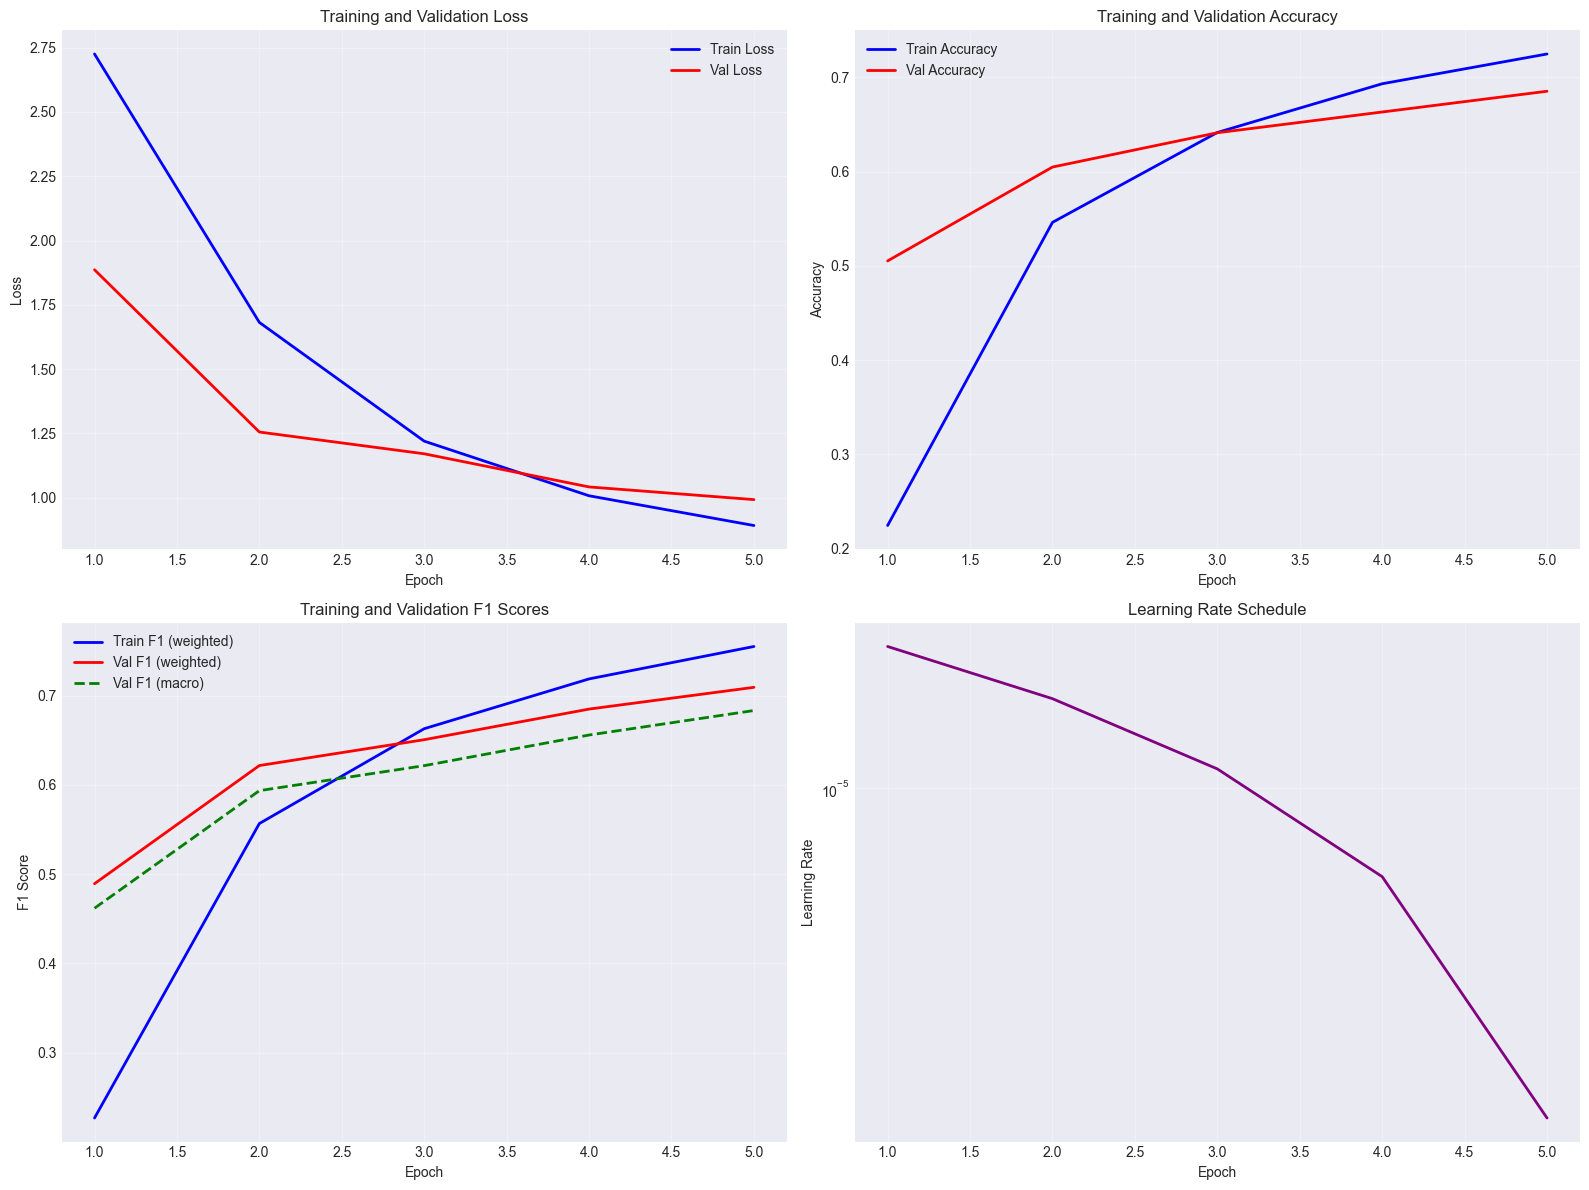

✓ Training curves saved


In [ ]:
# Create visualizations directory
viz_dir = project_root / 'results' / 'visualizations'
viz_dir.mkdir(parents=True, exist_ok=True)

# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, history['train_accuracy'], 'b-', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(epochs, history['val_accuracy'], 'r-', label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1 Score
axes[1, 0].plot(epochs, history['train_f1'], 'b-', label='Train F1 (weighted)', linewidth=2)
axes[1, 0].plot(epochs, history['val_f1_weighted'], 'r-', label='Val F1 (weighted)', linewidth=2)
axes[1, 0].plot(epochs, history['val_f1_macro'], 'g--', label='Val F1 (macro)', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Training and Validation F1 Scores')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs, history['learning_rates'], 'purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(viz_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Training curves saved")


## 9. Evaluate Model on Validation Set

Generate detailed evaluation metrics and confusion matrix.


In [ ]:
# Evaluate on validation set
model.eval()
all_predictions = []
all_labels = []

print("Evaluating on validation set...")
with torch.no_grad():
    for batch in tqdm(val_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        all_predictions.extend(predictions)
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
accuracy = accuracy_score(all_labels, all_predictions)
f1_weighted = f1_score(all_labels, all_predictions, average='weighted')
f1_macro = f1_score(all_labels, all_predictions, average='macro')

print("\n" + "=" * 80)
print("Validation Set Evaluation Results")
print("=" * 80)
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score (weighted): {f1_weighted:.4f}")
print(f"F1 Score (macro): {f1_macro:.4f}")
print("=" * 80)

# Classification report
print("\nPer-class Classification Report:")
target_names = [id_to_label[i] for i in range(NUM_CLASSES)]
print(classification_report(all_labels, all_predictions, target_names=target_names, digits=4))


Evaluating on validation set...


100%|██████████| 66/66 [04:46<00:00,  4.34s/it]


Validation Set Evaluation Results
Accuracy: 0.6852
F1 Score (weighted): 0.7092
F1 Score (macro): 0.6833

Per-class Classification Report:
               precision    recall  f1-score   support

  Agriculture     0.9286    0.4333    0.5909        30
  Automobiles     0.8667    0.7027    0.7761        37
         Bank     0.8148    0.7174    0.7630        92
         Blog     0.6512    0.7179    0.6829        39
     Business     0.4571    0.3478    0.3951        46
      Economy     0.7826    0.6000    0.6792        90
    Education     0.7429    0.9286    0.8254        28
   Employment     0.8485    0.6087    0.7089        46
Entertainment     0.7000    0.6632    0.6811        95
       Health     0.1595    0.9630    0.2737        27
    Interview     0.4865    0.3673    0.4186        49
   Literature     0.6471    0.5946    0.6197        37
    Migration     0.7778    0.8235    0.8000        17
      Opinion     0.8732    0.8267    0.8493        75
     Politics     0.9518    0.9634 

## 10. Confusion Matrix

Visualize the confusion matrix to understand classification patterns.


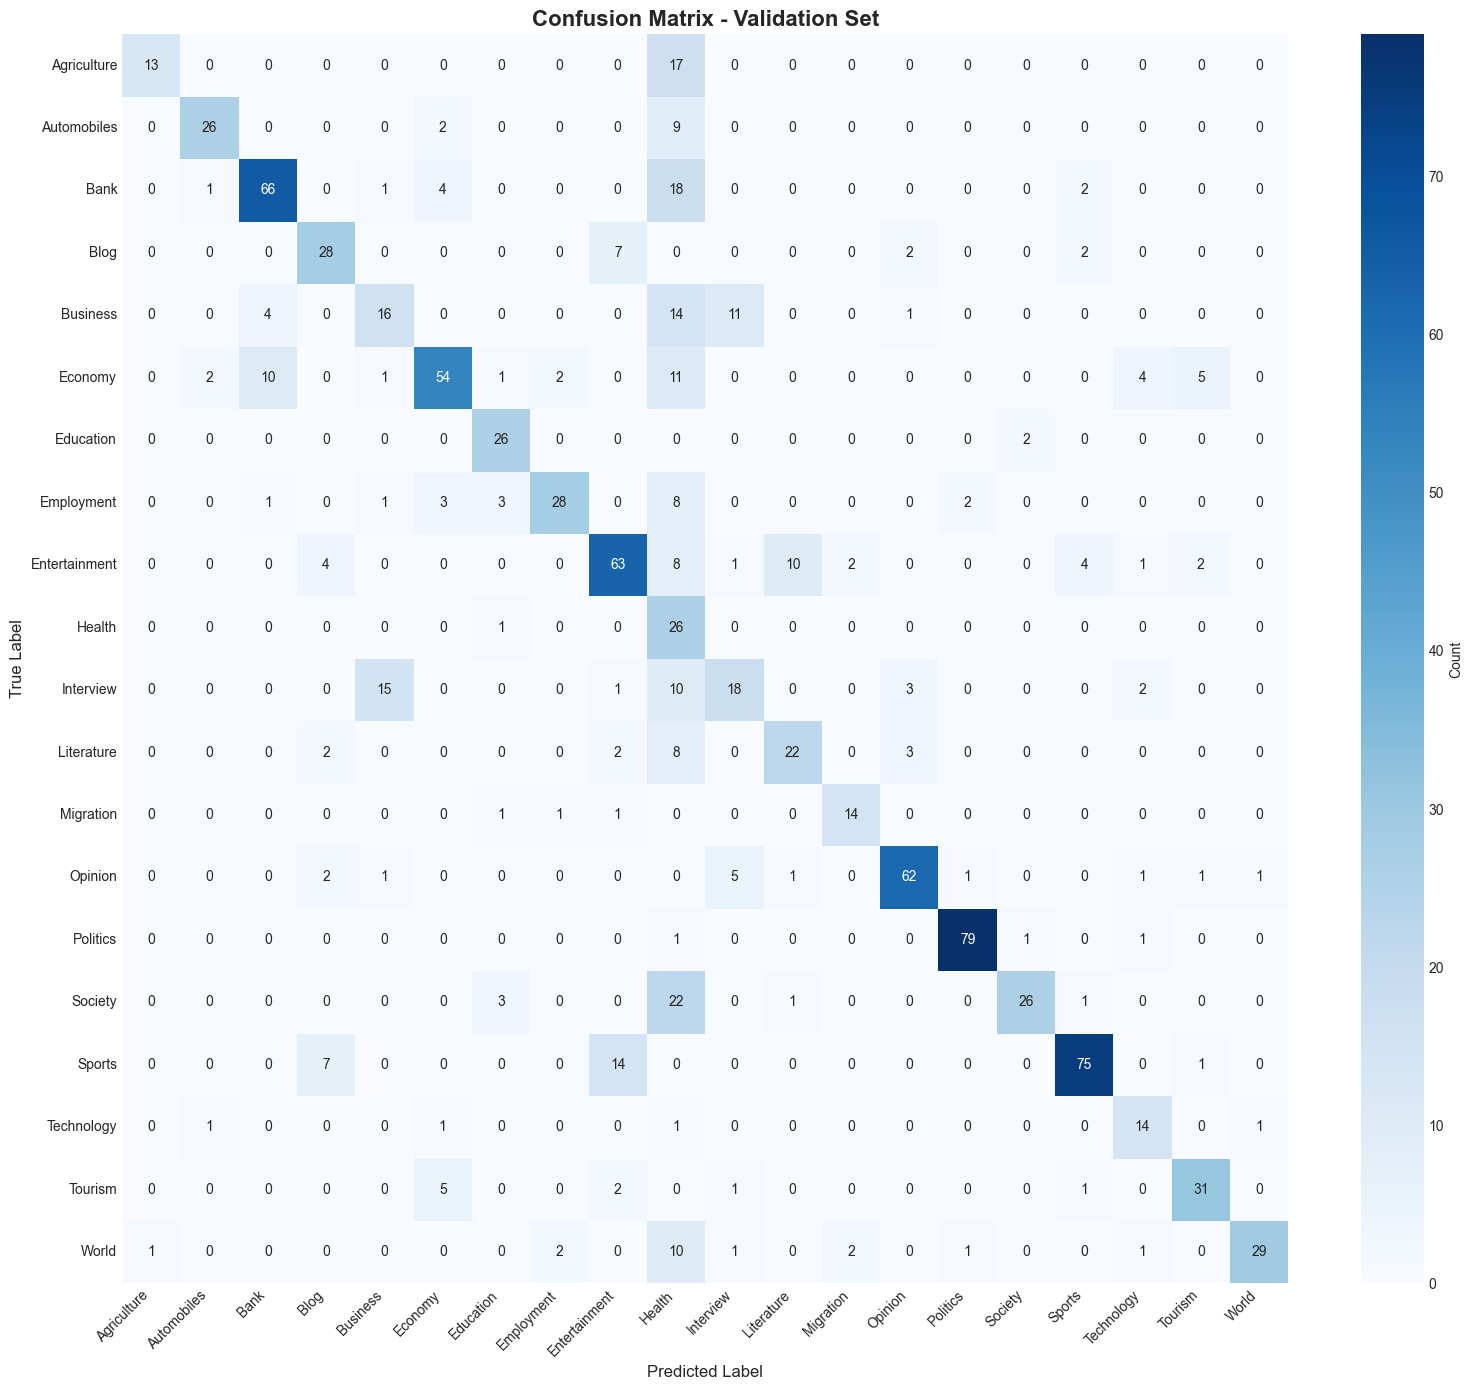

✓ Confusion matrix saved


In [ ]:
# Generate confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    yticklabels=[id_to_label[i] for i in range(NUM_CLASSES)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Validation Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(viz_dir / 'confusion_matrix_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved")


## 11. Training Summary

Generate a summary of the training process and results.


In [ ]:
# Create training summary
best_epoch_idx = history['val_f1_weighted'].index(max(history['val_f1_weighted']))
summary = {
    'model_name': MODEL_NAME,
    'num_classes': NUM_CLASSES,
    'training_samples': len(train_df),
    'validation_samples': len(val_df),
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'num_epochs_trained': len(history['train_loss']),
    'best_epoch': best_epoch_idx + 1,
    'best_val_f1_weighted': max(history['val_f1_weighted']),
    'best_val_f1_macro': history['val_f1_macro'][best_epoch_idx],
    'best_val_accuracy': history['val_accuracy'][best_epoch_idx],
    'best_train_loss': history['train_loss'][best_epoch_idx],
    'best_train_accuracy': history['train_accuracy'][best_epoch_idx],
    'best_train_f1': history['train_f1'][best_epoch_idx],
    'final_train_loss': history['train_loss'][-1],
    'final_val_loss': history['val_loss'][-1],
    'final_train_accuracy': history['train_accuracy'][-1],
    'final_val_accuracy': history['val_accuracy'][-1],
    'final_train_f1': history['train_f1'][-1],
    'final_val_f1_weighted': history['val_f1_weighted'][-1],
    'final_val_f1_macro': history['val_f1_macro'][-1],
    'validation_accuracy': float(accuracy),
    'validation_f1_weighted': float(f1_weighted),
    'validation_f1_macro': float(f1_macro),
    'device_used': str(device),
    'cuda_device_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad)
}

# Save summary as JSON
summary_json_path = models_dir / 'training_summary.json'
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved training summary (JSON) to {summary_json_path}")

# Save summary as readable text file
summary_txt_path = models_dir / 'training_summary.txt'
with open(summary_txt_path, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("NEPALI NEWS CLASSIFICATION - TRAINING SUMMARY\n")
    f.write("=" * 80 + "\n\n")
    
    f.write("MODEL CONFIGURATION\n")
    f.write("-" * 80 + "\n")
    f.write(f"Model Name: {summary['model_name']}\n")
    f.write(f"Number of Classes: {summary['num_classes']}\n")
    f.write(f"Device Used: {summary['device_used']}\n")
    f.write(f"CUDA Device: {summary['cuda_device_name']}\n")
    f.write(f"Total Parameters: {summary['total_parameters']:,}\n")
    f.write(f"Trainable Parameters: {summary['trainable_parameters']:,}\n\n")
    
    f.write("DATASET INFORMATION\n")
    f.write("-" * 80 + "\n")
    f.write(f"Training Samples: {summary['training_samples']:,}\n")
    f.write(f"Validation Samples: {summary['validation_samples']:,}\n")
    f.write(f"Batch Size: {summary['batch_size']}\n")
    f.write(f"Learning Rate: {summary['learning_rate']}\n\n")
    
    f.write("TRAINING RESULTS\n")
    f.write("-" * 80 + "\n")
    f.write(f"Epochs Trained: {summary['num_epochs_trained']}\n")
    f.write(f"Best Epoch: {summary['best_epoch']}\n\n")
    
    f.write("BEST EPOCH METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"Train Loss: {summary['best_train_loss']:.4f}\n")
    f.write(f"Train Accuracy: {summary['best_train_accuracy']:.4f}\n")
    f.write(f"Train F1 Score: {summary['best_train_f1']:.4f}\n")
    f.write(f"Val Loss: {history['val_loss'][best_epoch_idx]:.4f}\n")
    f.write(f"Val Accuracy: {summary['best_val_accuracy']:.4f}\n")
    f.write(f"Val F1 Score (weighted): {summary['best_val_f1_weighted']:.4f}\n")
    f.write(f"Val F1 Score (macro): {summary['best_val_f1_macro']:.4f}\n\n")
    
    f.write("FINAL EPOCH METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"Train Loss: {summary['final_train_loss']:.4f}\n")
    f.write(f"Train Accuracy: {summary['final_train_accuracy']:.4f}\n")
    f.write(f"Train F1 Score: {summary['final_train_f1']:.4f}\n")
    f.write(f"Val Loss: {summary['final_val_loss']:.4f}\n")
    f.write(f"Val Accuracy: {summary['final_val_accuracy']:.4f}\n")
    f.write(f"Val F1 Score (weighted): {summary['final_val_f1_weighted']:.4f}\n")
    f.write(f"Val F1 Score (macro): {summary['final_val_f1_macro']:.4f}\n\n")
    
    f.write("VALIDATION SET EVALUATION\n")
    f.write("-" * 80 + "\n")
    f.write(f"Accuracy: {summary['validation_accuracy']:.4f}\n")
    f.write(f"F1 Score (weighted): {summary['validation_f1_weighted']:.4f}\n")
    f.write(f"F1 Score (macro): {summary['validation_f1_macro']:.4f}\n\n")
    
    f.write("EPOCH-BY-EPOCH METRICS\n")
    f.write("-" * 80 + "\n")
    f.write(f"{'Epoch':<8} {'Train Loss':<12} {'Train Acc':<12} {'Train F1':<12} {'Val Loss':<12} {'Val Acc':<12} {'Val F1 (W)':<12} {'Val F1 (M)':<12}\n")
    f.write("-" * 80 + "\n")
    for i in range(len(history['train_loss'])):
        f.write(f"{i+1:<8} {history['train_loss'][i]:<12.4f} {history['train_accuracy'][i]:<12.4f} "
                f"{history['train_f1'][i]:<12.4f} {history['val_loss'][i]:<12.4f} "
                f"{history['val_accuracy'][i]:<12.4f} {history['val_f1_weighted'][i]:<12.4f} "
                f"{history['val_f1_macro'][i]:<12.4f}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("END OF SUMMARY\n")
    f.write("=" * 80 + "\n")

print("\nTraining Summary:")
print("=" * 80)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")
print("=" * 80)
print(f"\n✓ Summary saved to {summary_json_path}")
print(f"✓ Summary saved to {summary_txt_path}")


✓ Saved training summary (JSON) to d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\models\training_summary.json

Training Summary:
model_name: xlm-roberta-base
num_classes: 20
training_samples: 4878
validation_samples: 1045
batch_size: 16
learning_rate: 0.0000
num_epochs_trained: 5
best_epoch: 5
best_val_f1_weighted: 0.7092
best_val_f1_macro: 0.6833
best_val_accuracy: 0.6852
best_train_loss: 0.8915
best_train_accuracy: 0.7247
best_train_f1: 0.7550
final_train_loss: 0.8915
final_val_loss: 0.9922
final_train_accuracy: 0.7247
final_val_accuracy: 0.6852
final_train_f1: 0.7550
final_val_f1_weighted: 0.7092
final_val_f1_macro: 0.6833
validation_accuracy: 0.6852
validation_f1_weighted: 0.7092
validation_f1_macro: 0.6833
device_used: cuda
cuda_device_name: NVIDIA GeForce RTX 2050
total_parameters: 278059028
trainable_parameters: 278059028

✓ Summary saved to d:\MSc Islington\NEural Networks and Deep Learning\Project\nepali_news_classification\models\traini